# Aufgabe 6a: Bestehendes CellCNN als Bonus-Baseline

Die Architektur aus 04c bleibt unverändert: linearer Zellfilter → ReLU → Mittelwert der höchsten 1 % Antworten → linearer Output. Wir laden ausschließlich vorhandene Full-Artefakte und prüfen deren Vorhersagen. Es findet kein Training statt.

Die drei vorab festgelegten Splits verwenden `gated_alive`, 37 Marker und `arcsinh(x/5)`. Alle bestehenden Dateien bleiben unverändert. Dieses Notebook vor 06b ausführen; neue Exporte liegen ausschließlich unter `results/tables/task6_*`.

**Dieser ausgeführte Lauf umfasst dieselben Splits 0–99 wie die drei Vergleichsmodelle.** Half-Max ist eine Selektion, kein Clustering. Modell und Trainingskonfiguration sind unverändert.


In [1]:
from pathlib import Path
import copy
import csv
import hashlib
import json
import os
import sys
import time
import warnings
from importlib.metadata import version

import flowkit as fk
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display

BONUS_SPLIT_IDS = [0, 1, 2]
SPLIT_IDS = BONUS_SPLIT_IDS
GATE, RUN_MODE, GATE_SUFFIX = "gated_alive", "full", "_alive"
COFACTOR, TOP_FRACTION = 5.0, 0.01
LEARNING_RATE, L2_COEFFICIENT = 0.01, 1e-4
TRAINING_CELLS_PER_INPUT, TRAINING_INPUTS_PER_DONOR = 3000, 200
PREDICTION_CELLS_PER_INPUT, PREDICTION_INPUTS_PER_DONOR = 20000, 5
SCALER_CELLS_PER_DONOR = 20000
FILTER_COUNTS, BATCH_SIZE = [3, 4, 5], 128
MAX_EPOCHS, EARLY_STOPPING_PATIENCE = 100, 5
EVALUATION_CELLS_PER_DONOR, EVALUATION_SEED = 20000, 63000
EXPECTED_EVENT_COUNTS = {"gated_alive": 3438750}

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "NK_cell_dataset").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "NK_cell_dataset/NK_cell_dataset"
FCS_DIR = DATA_ROOT / "NK_cell_dataset" / GATE
LABELS_PATH, MARKERS_PATH = DATA_ROOT / "NK_fcs_samples_with_labels.csv", DATA_ROOT / "NK_markers.csv"
TABLES = PROJECT_ROOT / "results/tables"
SPLITS_PATH = TABLES / "task4_donor_splits.csv"
sys.path.insert(0, str(PROJECT_ROOT))
from src.task4_artifacts import make_run_config, file_digest, validate_prediction_splits, validate_parameter_table
from src.task5_interpretation import SavedCellCNN, restore_scaler

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Gerät: {DEVICE}; PyTorch: {torch.__version__}; Bonus-Splits: {BONUS_SPLIT_IDS}")


# Gemeinsamer, explizit angeforderter 100-Split-Vergleich.
BONUS_SPLIT_IDS = list(range(100))
SPLIT_IDS = BONUS_SPLIT_IDS
TABLES = PROJECT_ROOT / "results/tables/task6_comparison_100"
SPLITS_PATH = TABLES / "task4_donor_splits.csv"


Gerät: cuda; PyTorch: 2.14.0+cu130; Bonus-Splits: [0, 1, 2]


In [2]:
# Zweck: Alle Spenderdaten transformiert, aber weiterhin spenderweise getrennt laden.
with MARKERS_PATH.open(newline="", encoding="utf-8-sig") as stream:
    markers = next(csv.reader(stream))

label_table = pd.read_csv(LABELS_PATH)
label_table["donor_id"] = label_table["fcs_filename"].str.replace(
    r"_NK\.fcs$", "", regex=True
)
label_table["label"] = label_table["label"].astype(int)
fcs_paths = sorted(FCS_DIR.glob("*.fcs"))
fcs_table = pd.DataFrame(
    {
        "donor_id": [path.stem.removesuffix(GATE_SUFFIX) for path in fcs_paths],
        "fcs_path": fcs_paths,
    }
)
sample_table = (
    label_table[["donor_id", "label"]]
    .merge(fcs_table, on="donor_id", validate="one_to_one")
    .sort_values("donor_id")
    .reset_index(drop=True)
)
donor_splits = pd.read_csv(SPLITS_PATH)

assert len(markers) == 37
assert len(fcs_paths) == 20
assert len(sample_table) == 20
assert set(SPLIT_IDS).issubset(set(donor_splits["split_id"]))
split_labels = donor_splits[["donor_id", "label"]].drop_duplicates()
assert split_labels.merge(
    sample_table[["donor_id", "label"]],
    on=["donor_id", "label"],
    validate="one_to_one",
).shape[0] == len(sample_table)

def load_transformed_fcs(path: Path) -> np.ndarray:
    """Eine FCS-Datei read-only als ArcSinh-transformierte Markermatrix laden."""
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore", message=r"FCS file .* reported incorrect data offset.*"
        )
        sample = fk.Sample(str(path), ignore_offset_error=True)
    frame = sample.as_dataframe(source="raw")
    short_names = pd.Index(sample.pns_labels, name="marker")
    if not short_names.is_unique:
        raise ValueError(f"Doppelte FCS-Kurznamen in {path.name}.")
    frame.columns = short_names
    missing = [marker for marker in markers if marker not in frame.columns]
    if missing:
        raise ValueError(f"Fehlende Marker in {path.name}: {missing}")
    values = frame.loc[:, markers].to_numpy(dtype=np.float32, copy=True)
    values = np.arcsinh(values / COFACTOR).astype(np.float32, copy=False)
    if not np.isfinite(values).all():
        raise ValueError(f"Nicht-endliche Werte in {path.name}.")
    return values

# Die getrennte Ablage verhindert ein versehentliches Aufteilen eines Spenders.
data_by_donor = {
    row.donor_id: load_transformed_fcs(row.fcs_path)
    for row in sample_table.itertuples(index=False)
}
label_by_donor = sample_table.set_index("donor_id")["label"].to_dict()
assert sum(map(len, data_by_donor.values())) == EXPECTED_EVENT_COUNTS[GATE]

display(
    pd.DataFrame(
        {
            "donor_id": list(data_by_donor),
            "label": [label_by_donor[x] for x in data_by_donor],
            "cells": [len(data_by_donor[x]) for x in data_by_donor],
        }
    )
)


,donor_id,label,cells
0,a_001,1,82324
1,a_002,1,108267
2,a_003,0,97529
3,a_004,0,140687
4,a_005,1,155335
5,a_006,0,90075
6,a_007,1,104805
7,a_009,0,216632
8,a_010,0,122209
9,a_011,0,258461


In [3]:
# Referenzcode und Eingabedaten prüfen, ohne 04c auszuführen oder Artefakte zu schreiben.
baseline_path = TABLES / "task4_cellcnn_predictions_gated_alive_full.csv"
baseline_config_path = baseline_path.with_suffix(".config.json")
baseline_config = json.loads(baseline_config_path.read_text())
expected_parameters = {
    "method": "cellcnn", "gate": GATE, "run_mode": RUN_MODE,
    "cofactor": COFACTOR, "learning_rate": LEARNING_RATE,
    "l2_coefficient": L2_COEFFICIENT, "top_fraction": TOP_FRACTION,
    "training_cells_per_input": TRAINING_CELLS_PER_INPUT,
    "training_inputs_per_donor": TRAINING_INPUTS_PER_DONOR,
    "prediction_cells_per_input": PREDICTION_CELLS_PER_INPUT,
    "prediction_inputs_per_donor": PREDICTION_INPUTS_PER_DONOR,
    "scaler_cells_per_donor": SCALER_CELLS_PER_DONOR,
    "filter_counts": FILTER_COUNTS, "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS, "patience": EARLY_STOPPING_PATIENCE,
    "threshold": 0.5, "implementation_version": "pytorch_materialized_v1",
    "model_format": "complete_filter_parameters_v1",
}
expected_config = make_run_config(
    baseline_config["parameters"] | expected_parameters,
    [SPLITS_PATH, LABELS_PATH, MARKERS_PATH, *fcs_paths],
    PROJECT_ROOT / "notebooks/04c_cellcnn.ipynb", [4, 6, 8, 10],
)
if baseline_config != expected_config:
    raise ValueError("Baseline-Konfiguration, Referenzcode oder Eingangsdaten passen nicht.")

baseline_predictions = pd.read_csv(baseline_path, float_precision="round_trip")
baseline_filters_path = TABLES / "task4_cellcnn_filters_gated_alive_full.csv"
baseline_filters = pd.read_csv(baseline_filters_path, float_precision="round_trip")
baseline_selection = pd.read_csv(TABLES / "task4_cellcnn_selection_gated_alive_full.csv")
baseline_predictions = baseline_predictions.loc[baseline_predictions.split_id.isin(BONUS_SPLIT_IDS)].copy()
baseline_filters = baseline_filters.loc[baseline_filters.split_id.isin(BONUS_SPLIT_IDS)].copy()
validate_prediction_splits(baseline_predictions, donor_splits)
validate_parameter_table(baseline_filters, baseline_predictions, markers, ["split_id", "filter_id"],
    ["filter_weight", "filter_bias", "output_weight_0", "output_weight_1",
     "output_bias_0", "output_bias_1", "output_weight_contrast", "scaler_mean", "scaler_scale"])
assert set(baseline_predictions.split_id) == set(BONUS_SPLIT_IDS)
for split_id in BONUS_SPLIT_IDS:
    split = donor_splits.loc[donor_splits.split_id.eq(split_id)]
    assert len(split) == 20 and split.donor_id.nunique() == 20
    assert split.outer_partition.eq("test").sum() == 6
    assert split.outer_partition.eq("train").sum() == 14
    assert set(split.loc[split.outer_partition.eq("train"), "inner_fold"]) == {0, 1, 2}
    selection = baseline_selection.loc[baseline_selection.split_id.eq(split_id)]
    assert len(selection) == 9
    assert set(zip(selection.inner_fold, selection.filter_count)) == {(f, k) for f in range(3) for k in FILTER_COUNTS}
    best = selection.sort_values(
        ["validation_accuracy", "validation_roc_auc", "best_validation_loss", "filter_count", "inner_fold"],
        ascending=[False, False, True, True, True]).iloc[0]
    assert selection.selected.sum() == 1 and bool(best.selected)
    filters = baseline_filters.loc[baseline_filters.split_id.eq(split_id)]
    pred = baseline_predictions.loc[baseline_predictions.split_id.eq(split_id)]
    assert filters.inner_fold.eq(best.inner_fold).all() and pred.selected_inner_fold.eq(best.inner_fold).all()
    assert filters.filter_id.nunique() == best.filter_count and pred.filter_count.eq(best.filter_count).all()
    assert np.allclose(filters.output_weight_contrast, filters.output_weight_1 - filters.output_weight_0)
    assert filters.scaler_scale.gt(0).all()
    for frame in [filters, pred]:
        assert frame.gate.eq(GATE).all() and frame.run_mode.eq(RUN_MODE).all()
        assert frame.top_fraction.eq(TOP_FRACTION).all()
    assert pred.score.between(0, 1).all()

# Identische Originalereignisse je Spender, unabhängig von Modell und Split.
evaluation_indices = {
    donor: np.random.default_rng(EVALUATION_SEED + i).choice(
        len(data_by_donor[donor]), min(EVALUATION_CELLS_PER_DONOR, len(data_by_donor[donor])), replace=False)
    for i, donor in enumerate(sorted(data_by_donor))
}
evaluation_config = {
    "baseline_config": baseline_config,
    "baseline_predictions_sha256": file_digest(baseline_path),
    "baseline_filters_sha256": file_digest(baseline_filters_path),
    "split_ids": BONUS_SPLIT_IDS, "evaluation_seed": EVALUATION_SEED,
    "evaluation_cells_per_donor": EVALUATION_CELLS_PER_DONOR,
    "selection": "largest_positive_output_contrast", "baseline_membership": "half_inner_training_maximum",
    "halfmax_zero_rule": "strict_response_greater_than_half_maximum",
    "event_indices_sha256": hashlib.sha256(b"".join(
        evaluation_indices[d].astype("<i8").tobytes() for d in sorted(evaluation_indices))).hexdigest(),
}
print("Baseline-Artefakte, Referenzcode und spenderweise Splits geprüft.")


Baseline-Artefakte, Referenzcode und spenderweise Splits geprüft.


## Phänotypassoziation auf Testspendern

Je Modell wird der Filter mit größtem **positiven Output-Kontrast** ausgewählt, unabhängig von den Testlabels. Dies bezeichnet die Auswahlregel, nicht zwingend den Filter mit dem größten tatsächlichen Vorhersagebeitrag. Die Population erfüllt `ReLU(wᵀx+b) > 0.5 * Trainingsmaximum`. Das Maximum stammt ausschließlich aus den inneren Trainingsspendern des ausgewählten Modells, nicht aus dessen Validierungs- oder Testspendern.

Pro Testspender verwenden beide Methoden dieselben bis zu 20.000 Originalzellen. Häufigkeiten gehen mit gleichem Spendergewicht in die CMV-Gruppenmittel ein. Ohne positiven Filter bleiben Phänotypmetriken fehlend; eine leere Population hat Häufigkeit null. Konstante Häufigkeiten ergeben ROC-AUC 0,5.
Die strikte Half-Max-Regel gilt auch bei Trainingsmaximum null: positive Testresponses werden gezählt.


In [4]:
def strongest_positive_filter(model):
    contrasts = (model.output_layer.weight[1] - model.output_layer.weight[0]).detach().cpu().numpy()
    positive = np.flatnonzero(contrasts > 0)
    return int(positive[np.argmax(contrasts[positive])]) if len(positive) else None


def summarize_split(predictions, frequencies, split_id):
    pred = predictions.loc[predictions.split_id.eq(split_id)]
    freq = frequencies.loc[frequencies.split_id.eq(split_id)]
    valid = len(freq) == len(pred) and freq.frequency.notna().all()
    return {
        "split_id": split_id,
        "network_auc": roc_auc_score(pred.y_true, pred.score),
        "frequency_auc": roc_auc_score(freq.y_true, freq.frequency) if valid else np.nan,
        "frequency_effect": (freq.loc[freq.y_true.eq(1), "frequency"].mean()
                             - freq.loc[freq.y_true.eq(0), "frequency"].mean()) if valid else np.nan,
        "phenotype_status": "berechnet" if valid else "kein positiver Output-Kontrast",
    }


In [5]:
frequency_rows, check_rows = [], []
for split_id in BONUS_SPLIT_IDS:
    split = donor_splits.loc[donor_splits.split_id.eq(split_id)]
    filters = baseline_filters.loc[baseline_filters.split_id.eq(split_id)]
    model = SavedCellCNN(filters, markers).to(DEVICE)
    filter_id = strongest_positive_filter(model)
    train_ids = sorted(split.loc[split.outer_partition.eq("train") &
                                 split.inner_fold.ne(int(filters.inner_fold.iloc[0])), "donor_id"])
    test_ids = sorted(split.loc[split.outer_partition.eq("test"), "donor_id"])
    assert len(train_ids) in (9, 10) and not set(train_ids) & set(test_ids)
    validation_ids = set(split.loc[split.outer_partition.eq("train"), "donor_id"]) - set(train_ids)
    assert len(validation_ids) in (4, 5) and not set(train_ids) & validation_ids
    maximum = 0.0
    with torch.no_grad():
        if filter_id is not None:
            for donor in train_ids:
                values = data_by_donor[donor]
                for start in range(0, len(values), 50000):
                    scaled = model.scaler.transform(values[start:start + 50000])
                    response = torch.relu(model.cell_filters(torch.from_numpy(scaled).to(DEVICE)))
                    maximum = max(maximum, float(response[:, filter_id].max()))
        for i, donor in enumerate(test_ids):
            # Originale Prediction-Bags aus 04c rekonstruieren, keine neuen Vorhersageparameter.
            values = data_by_donor[donor]
            rng = np.random.default_rng(int(split.split_seed.iloc[0]) + 900000 + i)
            probabilities = []
            for _ in range(PREDICTION_INPUTS_PER_DONOR):
                indices = rng.choice(len(values), min(PREDICTION_CELLS_PER_INPUT, len(values)), replace=False)
                bag = torch.from_numpy(model.scaler.transform(values[indices])).to(DEVICE)
                logits, _ = model(bag)
                probabilities.append(float(torch.softmax(logits, dim=0)[1]))
            expected = baseline_predictions.loc[baseline_predictions.split_id.eq(split_id) & baseline_predictions.donor_id.eq(donor)].iloc[0]
            error = abs(float(np.mean(probabilities)) - expected.score)
            assert error <= 1e-6, (split_id, donor, error)
            check_rows.append({"split_id": split_id, "donor_id": donor, "probability_error": error})
            indices = evaluation_indices[donor]
            frequency = n_selected_cells = np.nan
            if filter_id is not None:
                scaled = torch.from_numpy(model.scaler.transform(values[indices])).to(DEVICE)
                response = torch.relu(model.cell_filters(scaled))[:, filter_id]
                mask = response > maximum / 2
                n_selected_cells = int(mask.sum())
                frequency = n_selected_cells / len(indices)
            frequency_rows.append({"split_id": split_id, "donor_id": donor, "y_true": label_by_donor[donor],
                "filter_id": filter_id, "frequency": frequency, "n_selected_cells": n_selected_cells, "n_cells": len(indices),
                "response_threshold": maximum / 2 if filter_id is not None else np.nan,
                "training_donors": ";".join(train_ids)})
    print(f"Baseline-Split {split_id}: geladen; Vorhersagen rekonstruiert.")

baseline_frequencies = pd.DataFrame(frequency_rows)
baseline_metrics = pd.DataFrame([summarize_split(baseline_predictions, baseline_frequencies, s) for s in BONUS_SPLIT_IDS])
pd.DataFrame(check_rows).to_csv(TABLES / "task6_baseline_prediction_checks.csv", index=False)
baseline_frequencies.to_csv(TABLES / "task6_baseline_frequencies.csv", index=False)
baseline_metrics.to_csv(TABLES / "task6_baseline_metrics.csv", index=False)
baseline_export_config = evaluation_config | {
    "metrics_sha256": file_digest(TABLES / "task6_baseline_metrics.csv"),
    "frequencies_sha256": file_digest(TABLES / "task6_baseline_frequencies.csv"),
}
(TABLES / "task6_baseline_evaluation.config.json").write_text(json.dumps(baseline_export_config, indent=2) + "\n")
display(baseline_metrics.rename(columns={"network_auc": "Network-ROC-AUC", "frequency_auc": "Häufigkeits-ROC-AUC", "frequency_effect": "Häufigkeitsdifferenz CMV+ minus CMV−"}))
print("Kein Baseline-Training. Maximaler Rekonstruktionsfehler:", max(row["probability_error"] for row in check_rows))


Baseline-Split 0: geladen; Vorhersagen rekonstruiert.


Baseline-Split 1: geladen; Vorhersagen rekonstruiert.


Baseline-Split 2: geladen; Vorhersagen rekonstruiert.
Baseline-Split 3: geladen; Vorhersagen rekonstruiert.


Baseline-Split 4: geladen; Vorhersagen rekonstruiert.
Baseline-Split 5: geladen; Vorhersagen rekonstruiert.


Baseline-Split 6: geladen; Vorhersagen rekonstruiert.
Baseline-Split 7: geladen; Vorhersagen rekonstruiert.


...

Baseline-Split 94: geladen; Vorhersagen rekonstruiert.
Baseline-Split 95: geladen; Vorhersagen rekonstruiert.


Baseline-Split 96: geladen; Vorhersagen rekonstruiert.
Baseline-Split 97: geladen; Vorhersagen rekonstruiert.


Baseline-Split 98: geladen; Vorhersagen rekonstruiert.
Baseline-Split 99: geladen; Vorhersagen rekonstruiert.


,split_id,Network-ROC-AUC,Häufigkeits-ROC-AUC,Häufigkeitsdifferenz CMV+ minus CMV−,phenotype_status
0,0,1.000,1.0000,0.007350,berechnet
1,1,1.000,1.0000,0.033825,berechnet
2,2,1.000,1.0000,0.026438,berechnet
3,3,1.000,1.0000,0.009650,berechnet
4,4,0.875,0.8750,0.001888,berechnet
...,...,...,...,...,...
95,95,1.000,1.0000,0.011500,berechnet
96,96,0.250,1.0000,0.002063,berechnet
97,97,0.625,0.8125,0.013225,berechnet
98,98,0.875,1.0000,0.009388,berechnet


Kein Baseline-Training. Maximaler Rekonstruktionsfehler: 0.0


Die Network-AUC beruht auf den gespeicherten, hier rekonstruierten kontinuierlichen Donorscores. Die Häufigkeits-AUC beschreibt ausschließlich das ausgewählte Subset. Sechs Testspender je Split und überlappende Splits erlauben nur eine deskriptive Einordnung. Die Auswahl eines einzelnen positiven Filters ist eine bewusste Vereinfachung gegenüber der Vereinigung positiver Filter in Aufgabe 5.

## ROC-Kurven, Klassifikationsmetriken und Half-Max-Frequenzen

Die Abbildungen berechnen ROC-AUC, Average Precision und Balanced Accuracy (Schwelle 0,5) je Outer-Split. Frequency-AUC und Frequency-Effect verwenden den stärksten positiven Output-Kontrast und die strikte Auswahl `h > 0.5 * max(h_inner_train)`, auch bei M=0. Ohne positiven Filter bleiben die Frequency-Metriken fehlend. Dies ist eine Zellselektion, kein Clustering.

ROC-Kurven werden je Split berechnet und anschließend gemittelt; die Legende zeigt die mittlere ursprüngliche Split-AUC. Boxen und Punkte beschreiben die Streuung über überlappende Splits. Donorfrequenzen werden zuerst über die Testauftritte desselben Spenders gemittelt. Der gemeinsame 100-Split-Lauf und die Folien verwenden für Frequency-Vergleiche nur die bei allen vier Methoden bestimmbaren Splits.


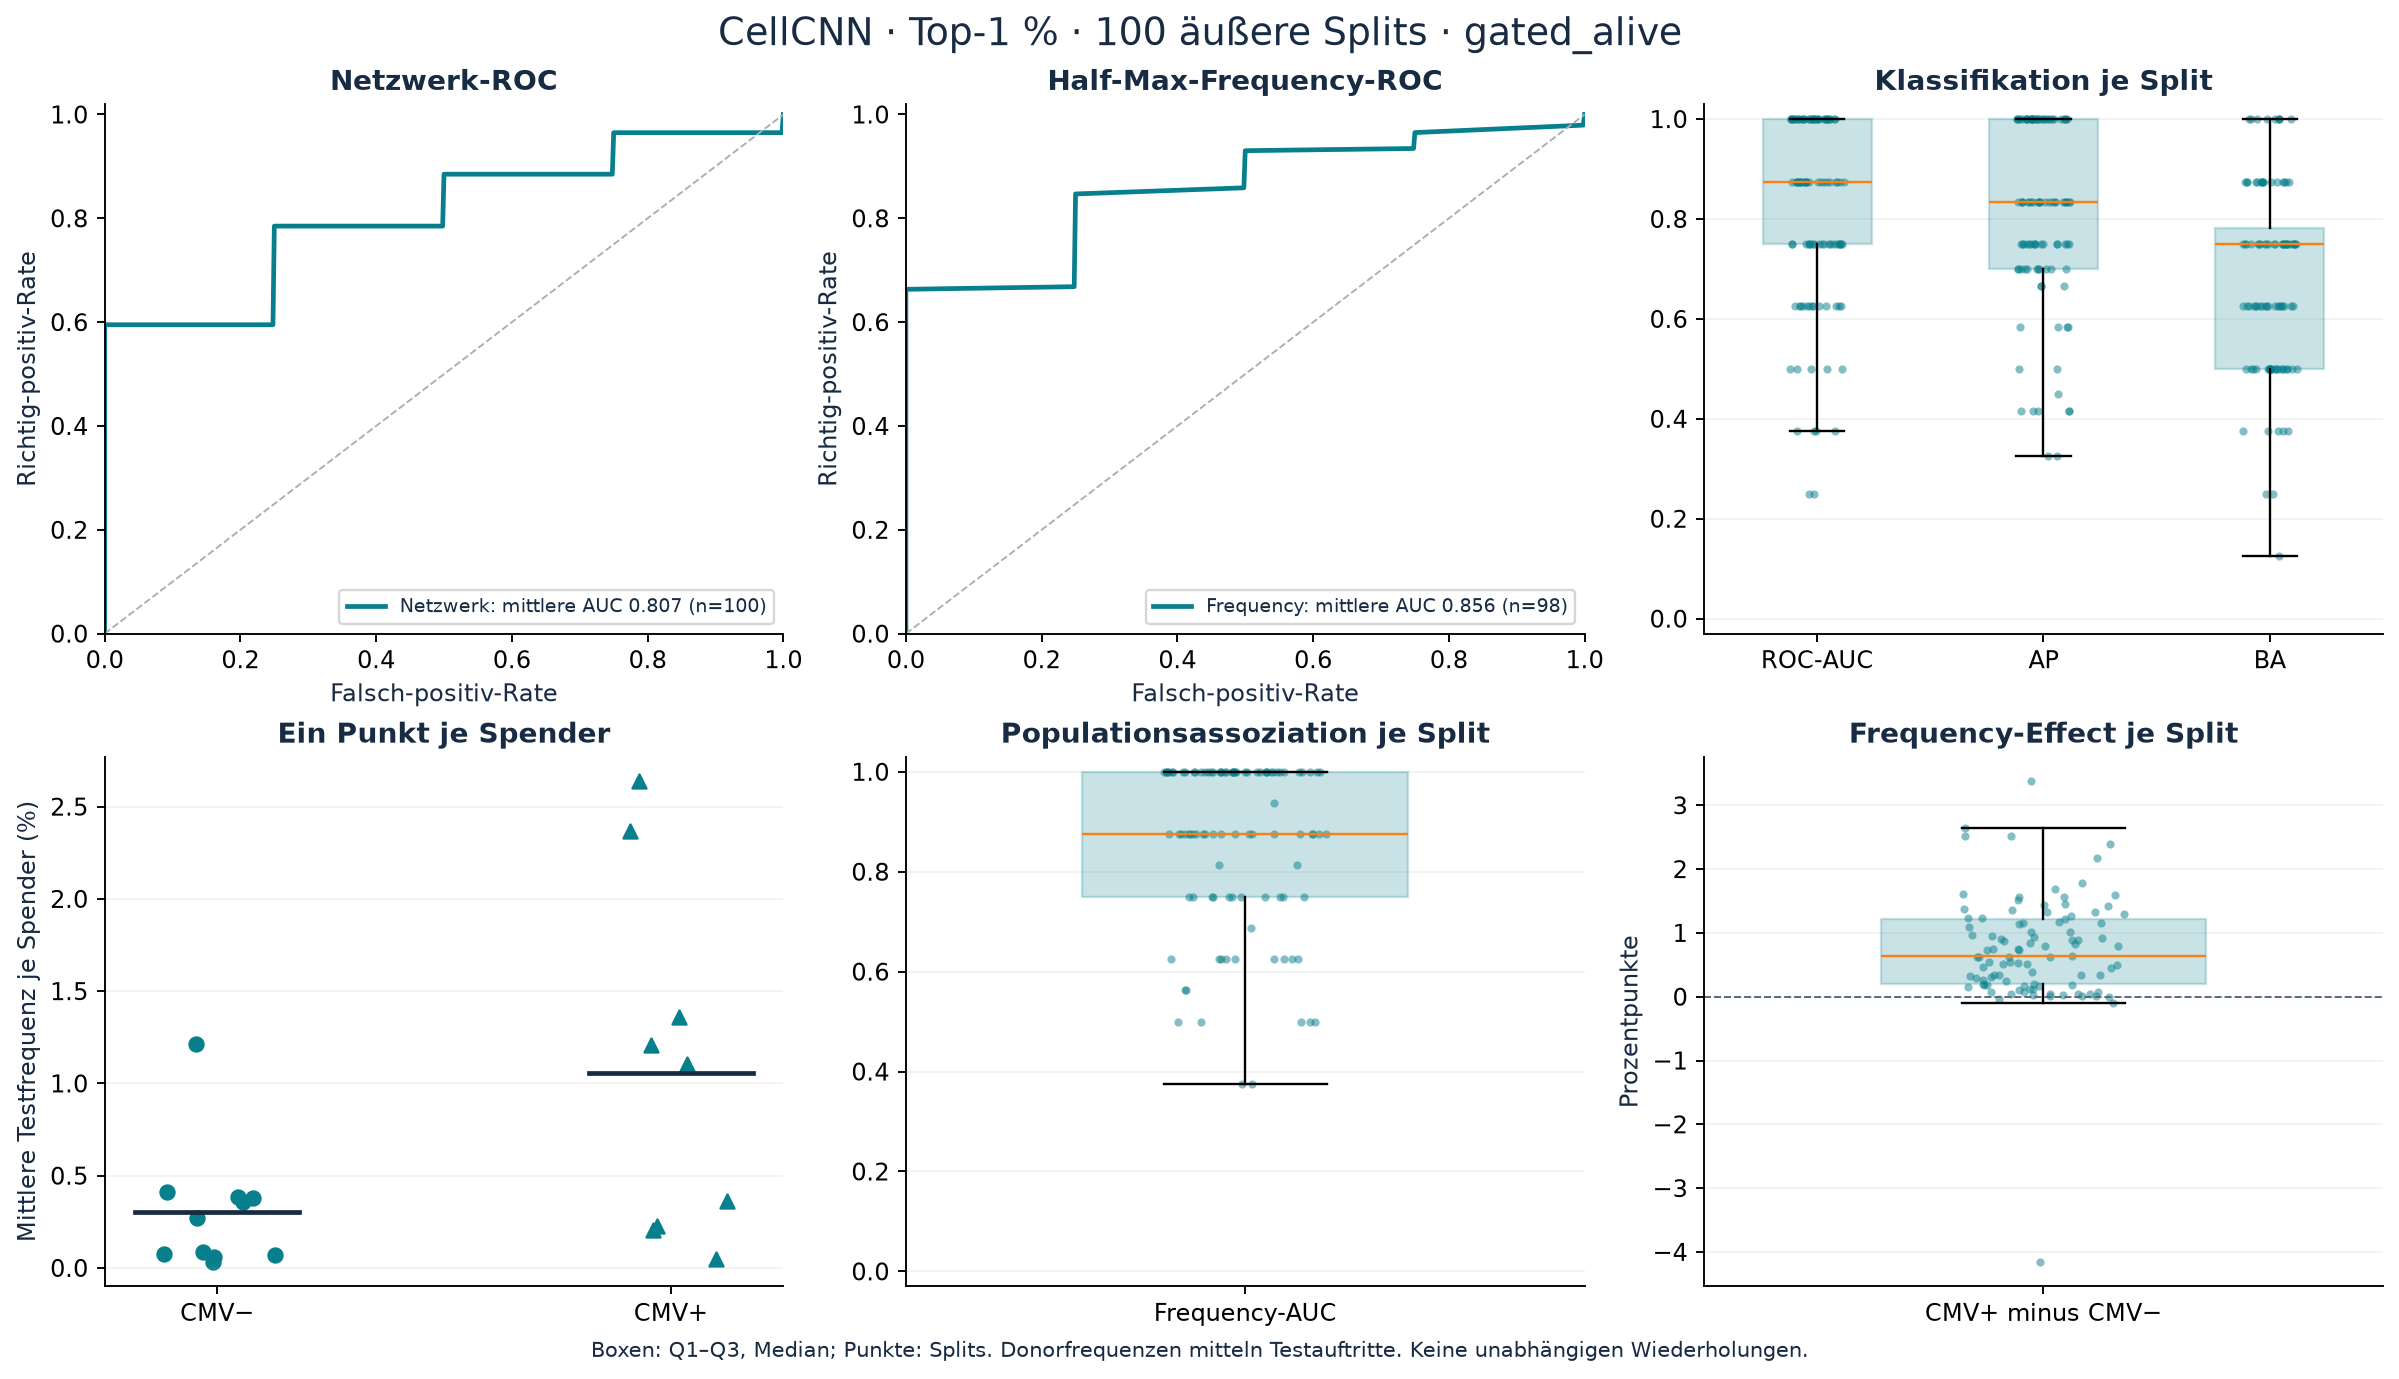

In [6]:
from src.task6_comparison import plot_model_results
from IPython.display import Image

plot_path = plot_model_results(baseline_predictions, baseline_frequencies, TABLES / "plots/cellcnn", "cellcnn", donor_splits)
display(Image(filename=str(plot_path)))
